In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt
import pickle

url = "https://raw.githubusercontent.com/4GeeksAcademy/alternative-time-series-project/main/sales.csv"

data = pd.read_csv(url)

print(data.head())

                         date      sales
0  2022-09-03 17:10:08.079328  55.292157
1  2022-09-04 17:10:08.079328  53.803211
2  2022-09-05 17:10:08.079328  58.141693
3  2022-09-06 17:10:08.079328  64.530899
4  2022-09-07 17:10:08.079328  66.013633


In [ ]:

data["date"] = pd.to_datetime(data["date"])
data.set_index("date", inplace=True)
data = data.sort_index()
print(data.head())

                                sales
date                                 
2022-09-03 17:10:08.079328  55.292157
2022-09-04 17:10:08.079328  53.803211
2022-09-05 17:10:08.079328  58.141693
2022-09-06 17:10:08.079328  64.530899
2022-09-07 17:10:08.079328  66.013633


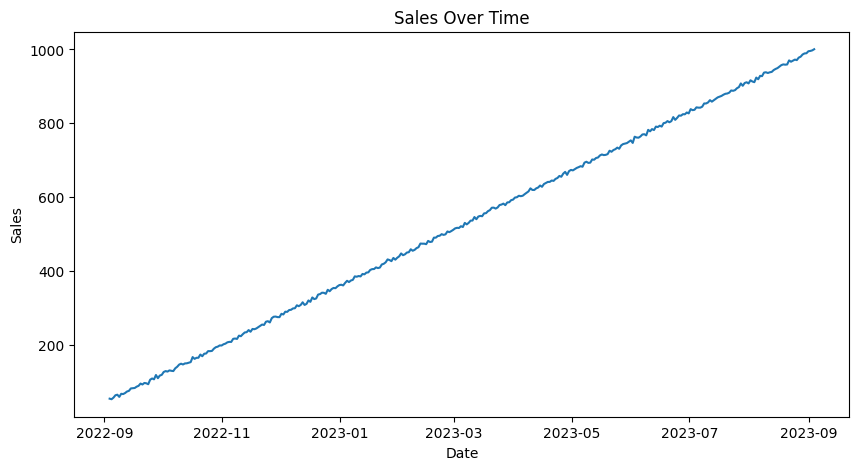

In [4]:
plt.figure(figsize=(10,5))
plt.plot(data["sales"])
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [10]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(data["sales"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.5454141937063742
p-value: 0.9861899815311063


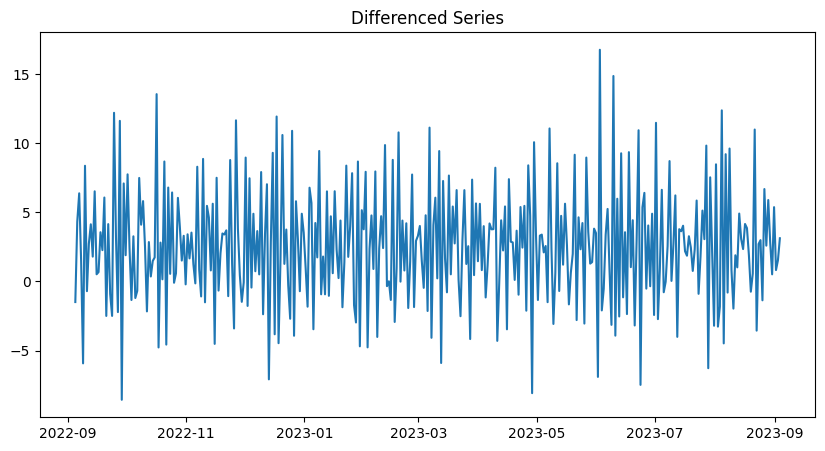

In [11]:
data_diff = data["sales"].diff().dropna()

plt.figure(figsize=(10,5))
plt.plot(data_diff)
plt.title("Differenced Series")
plt.show()

In [14]:
train_size = int(len(data) * 0.8)
train, test = data["sales"][:train_size], data["sales"][train_size:]
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/python/3.12.1/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  292
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -838.546
Date:                Mon, 06 Apr 2026   AIC                           1683.093
Time:                        21:37:27   BIC                           1694.113
Sample:                    09-03-2022   HQIC                          1687.508
                         - 06-21-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.001    670.268      0.000       0.997       1.003
ma.L1         -0.9995      1.064     -0.939      0.348      -3.085       1.086
sigma2        18.3542     19.579      0.937      0.3

In [15]:
# Forecast
predictions = model_fit.forecast(steps=len(test))

# Evaluate
rmse = sqrt(mean_squared_error(test, predictions))
print("RMSE:", rmse)

RMSE: 4.081205256775362


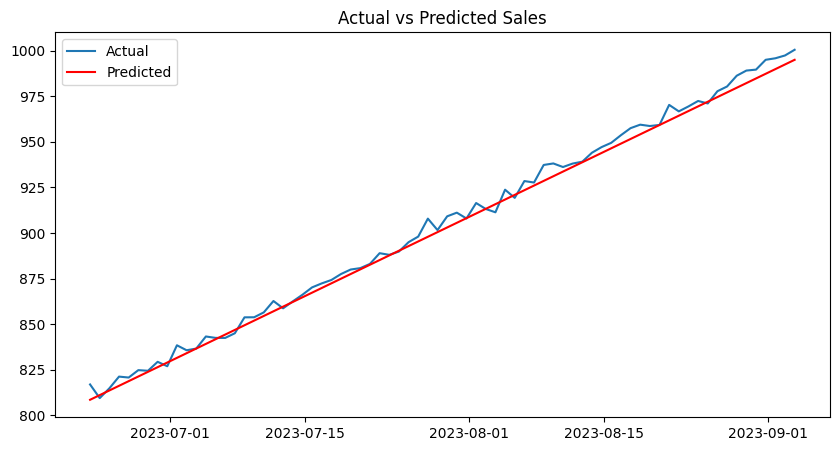

In [16]:
plt.figure(figsize=(10,5))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, predictions, label="Predicted", color="red")
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [17]:
import os

# Create folder if not exists
os.makedirs("../models", exist_ok=True)

# Save model
with open("../models/arima_model.pkl", "wb") as f:
    pickle.dump(model_fit, f)

print("Model saved successfully!")

Model saved successfully!
